# NOTEBOOK 05 — Out-of-Sample Test

---

## Objective

This notebook performs the **definitive validation** of the momentum
strategy. We apply the model selected in Notebook 04d — the
**Sector-Neutral 12-1 Momentum with Volatility Scaling (target = 8%)**
— to the out-of-sample period (2019–2024).

This is the **only time** the out-of-sample data is examined.
No modifications to the model are permitted after seeing these results.

---

## Selected Model

| Component | Specification |
|---|---|
| Signal | 12-1 month momentum (formation 252d, skip 21d) |
| Ranking | Sector-neutral (within GICS sector) |
| Portfolio | Equal-weight, dollar-neutral long/short (Q5 − Q1) |
| Rebalancing | Monthly (K=1) |
| Vol scaling | Target = 8%, window = 21 days, max weight = 2.0 |
| Costs | 5 bps/trade + 0.5% borrow fee annual |

---

## The Out-of-Sample Period: 2019–2024

This period covers five distinct market regimes, each more
challenging than anything seen in the in-sample period:

| Year | Regime | Why it challenges momentum |
|---|---|---|
| 2019 | Late bull market | Low dispersion, crowded trades |
| 2020 | COVID crash & recovery | Fastest reversal in history |
| 2021 | Post-COVID bull run | Meme stocks, narrative-driven moves |
| 2022 | Bear market | Rate hike shock, sector rotation |
| 2023 | AI-driven recovery | Extreme mega-cap concentration |
| 2024 | Rotation | Return to broader market participation |

---

## Benchmark Comparison

We compare the strategy against:
1. **In-sample performance** — did performance hold up OOS?
2. **Unscaled sector-neutral** — does vol scaling still help OOS?
3. **Global 12-1 baseline** — how much did our improvements add?

---

## Methodological Note on Research Process

The volatility scaling specification and model selection were
finalized on in-sample data only. However, the researcher had
prior knowledge of the general out-of-sample environment from
earlier exploratory analysis (Notebook 05 first iteration).
This represents a mild form of look-ahead bias at the research
level and is acknowledged here in the interest of full transparency.
This does not affect the quantitative results but should be
considered when interpreting them.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load full price dataset
prices = pd.read_parquet('../data/sp500_prices.parquet').ffill(limit=5)

# Period definitions
IS_START  = '2011-01-01'
IS_END    = '2018-12-31'
OOS_START = '2019-01-01'
OOS_END   = '2024-12-30'

# Load IS portfolio returns for comparison
port_global_is = pd.read_parquet(
    '../data/portfolio_returns.parquet'
)['gross'].loc[IS_START:IS_END]
port_sn_is = pd.read_parquet(
    '../data/portfolio_returns_sn.parquet'
)['gross'].loc[IS_START:IS_END]

print("=== DATA LOADED ===")
print(f"In-sample:     {IS_START} → {IS_END}")
print(f"Out-of-sample: {OOS_START} → {OOS_END}")
print(f"Tickers:       {prices.shape[1]}")

=== DATA LOADED ===
In-sample:     2011-01-01 → 2018-12-31
Out-of-sample: 2019-01-01 → 2024-12-30
Tickers:       449


## Step 1 — Build Out-of-Sample Signal

We apply the sector-neutral 12-1 momentum signal to the
out-of-sample period using the full price history for signal
formation. Computing the signal at January 2019 requires
price history back to January 2018 — this is legitimate
use of past prices, not lookahead bias.

The sector assignments are identical to those used in-sample
(current S&P 500 GICS sectors from Wikipedia).

In [5]:
import requests

def get_sp500_sectors():
    url      = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    headers  = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers)
    table    = pd.read_html(response.text)[0]
    sm       = table[['Symbol', 'GICS Sector']].copy()
    sm['Symbol'] = sm['Symbol'].str.replace('.', '-', regex=False)
    return sm.set_index('Symbol')

def compute_momentum(prices, formation_long=252,
                     formation_short=21, min_obs=200):
    price_long   = prices.shift(formation_long)
    price_short  = prices.shift(formation_short)
    momentum_raw = (price_short / price_long) - 1
    valid_obs    = (
        prices.pct_change()
        .rolling(window=formation_long, min_periods=min_obs)
        .count()
    )
    return momentum_raw.where(valid_obs >= min_obs)

def compute_sn_ranks(momentum, sector_map, min_stocks=5):
    sn_ranks = pd.DataFrame(
        np.nan,
        index=momentum.index,
        columns=momentum.columns
    )
    sectors = sector_map['GICS Sector'].unique()
    for date in momentum.index:
        row = momentum.loc[date]
        for sector in sectors:
            tickers_s = sector_map[
                sector_map['GICS Sector'] == sector
            ].index
            valid = tickers_s[
                tickers_s.isin(row.index) & row[tickers_s].notna()
            ]
            if len(valid) < min_stocks:
                continue
            sn_ranks.loc[date, valid] = row[valid].rank(pct=True)
    return sn_ranks

def ranks_to_quintiles(sn_ranks):
    quintiles = pd.DataFrame(
        np.nan,
        index=sn_ranks.index,
        columns=sn_ranks.columns
    )
    bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    for date in sn_ranks.index:
        row   = sn_ranks.loc[date]
        valid = row.notna()
        if valid.sum() < 10:
            continue
        quintiles.loc[date, valid] = pd.cut(
            row[valid], bins=bins,
            labels=[1, 2, 3, 4, 5],
            include_lowest=True
        ).astype(float)
    return quintiles

# Load sector map
sector_map = get_sp500_sectors()
valid_tickers = prices.columns.tolist()
sector_map = sector_map.loc[sector_map.index.isin(valid_tickers)]

# Compute signal on full dataset
print("Computing momentum signal (full dataset)...")
momentum_full = compute_momentum(prices)

print("Computing sector-neutral ranks (full dataset)...")
print("(This may take 3-5 minutes)")
sn_ranks_full = compute_sn_ranks(momentum_full, sector_map)

# Split to OOS only
sn_ranks_oos  = sn_ranks_full.loc[OOS_START:OOS_END]
quintiles_oos = ranks_to_quintiles(sn_ranks_oos)

print(f"\n=== OOS SIGNAL COMPUTED ===")
print(f"OOS ranks shape:     {sn_ranks_oos.shape}")
print(f"First valid date:    "
      f"{sn_ranks_oos.dropna(how='all').index[0].date()}")

Computing momentum signal (full dataset)...
Computing sector-neutral ranks (full dataset)...
(This may take 3-5 minutes)

=== OOS SIGNAL COMPUTED ===
OOS ranks shape:     (1509, 449)
First valid date:    2019-01-02


## Step 2 — IC Analysis: Does the Signal Predict OOS?

Before evaluating portfolio performance, we verify that the
sector-neutral signal maintains its predictive power out-of-sample.

This is an important diagnostic: if the IC collapses OOS, any
portfolio underperformance is a signal failure. If the IC holds
but portfolio returns are negative, the problem is in the
implementation or market regime — not the signal itself.

In [8]:
HOLDING_DAYS = 21

def compute_ic_series(signal, prices, holding_days=21, min_stocks=50):
    fwd_returns = prices.pct_change(holding_days).shift(-holding_days)
    records     = []
    month_ends  = signal.resample('M').last().index

    for date in month_ends:
        if date not in signal.index:
            continue
        sig     = signal.loc[date]
        forward = fwd_returns.loc[date]
        valid   = sig.notna() & forward.notna()
        if valid.sum() < min_stocks:
            continue
        ic, _   = stats.spearmanr(sig[valid], forward[valid])
        records.append({'date': date, 'ic': ic,
                        'n_stocks': valid.sum()})

    return pd.DataFrame(records).set_index('date')

# Load IS IC for comparison
ic_is = pd.read_parquet('../data/ic_series.parquet')

# Compute OOS IC
prices_oos = prices.loc[OOS_START:OOS_END]
ic_oos     = compute_ic_series(sn_ranks_oos, prices_oos)

def summarize_ic(ic_df, label):
    ic       = ic_df['ic']
    mean_ic  = ic.mean()
    std_ic   = ic.std()
    icir     = mean_ic / std_ic
    hit_rate = (ic > 0).mean() * 100
    t_stat, p_value = stats.ttest_1samp(ic, 0)

    print(f"\n  {label}")
    print(f"    Observations: {len(ic)}")
    print(f"    Mean IC:      {mean_ic:+.4f}")
    print(f"    IC Std:       {std_ic:.4f}")
    print(f"    ICIR:         {icir:+.4f}")
    print(f"    Hit Rate:     {hit_rate:.1f}%")
    print(f"    t-statistic:  {t_stat:.3f}")
    print(f"    p-value:      {p_value:.4f}")

    return {
        'Mean IC': mean_ic, 'IC Std': std_ic,
        'ICIR': icir, 'Hit Rate': hit_rate,
        'p-value': p_value, 'N': len(ic)
    }

print("=" * 55)
print("   IC ANALYSIS — IS vs OOS")
print("=" * 55)
stats_is  = summarize_ic(ic_is,  'In-Sample  (2011-2018)')
stats_oos = summarize_ic(ic_oos, 'Out-of-Sample (2019-2024)')
print("=" * 55)

   IC ANALYSIS — IS vs OOS

  In-Sample  (2011-2018)
    Observations: 67
    Mean IC:      +0.0120
    IC Std:       0.1667
    ICIR:         +0.0718
    Hit Rate:     53.7%
    t-statistic:  0.588
    p-value:      0.5587

  Out-of-Sample (2019-2024)
    Observations: 49
    Mean IC:      +0.0239
    IC Std:       0.1580
    ICIR:         +0.1513
    Hit Rate:     65.3%
    t-statistic:  1.059
    p-value:      0.2950


## Step 3 — Build Out-of-Sample Portfolio

We apply the complete model pipeline to the OOS period:
1. Sector-neutral quintile assignment
2. Equal-weighted monthly returns
3. Monthly turnover and transaction costs
4. Volatility scaling (target = 8%)

The volatility scaling uses realized market volatility estimated
from OOS price data — this is not lookahead bias because we use
the previous month's volatility to scale each month's return.

In [11]:
def compute_quintile_returns(prices, quintiles):
    monthly_prices    = prices.resample('M').last()
    monthly_returns   = monthly_prices.pct_change()
    monthly_quintiles = quintiles.resample('M').last()
    records = []

    for i in range(1, len(monthly_prices)):
        date_signal = monthly_prices.index[i-1]
        date_return = monthly_prices.index[i]
        if date_signal not in monthly_quintiles.index:
            continue
        q_assign   = monthly_quintiles.loc[date_signal]
        month_rets = monthly_returns.loc[date_return]
        row = {'date': date_return}
        for q in range(1, 6):
            mask   = (q_assign == q) & month_rets.notna()
            stocks = month_rets[mask]
            row[f'Q{q}'] = stocks.mean() if len(stocks) > 0 else np.nan
        records.append(row)

    return pd.DataFrame(records).set_index('date')

def compute_monthly_costs(quintiles, cost_bps=5, borrow_annual=0.005):
    monthly_q      = quintiles.resample('M').last()
    cost_per_trade = cost_bps / 10000
    borrow_monthly = borrow_annual / 12
    records        = []

    for i in range(1, len(monthly_q)):
        date_curr = monthly_q.index[i]
        date_prev = monthly_q.index[i-1]
        q_curr    = monthly_q.loc[date_curr]
        q_prev    = monthly_q.loc[date_prev]
        total_to  = 0
        for q in [1, 5]:
            s_curr      = set(q_curr[q_curr == q].index)
            s_prev      = set(q_prev[q_prev == q].index)
            new_entries = s_curr - s_prev
            total_to   += (
                len(new_entries) / len(s_curr)
                if len(s_curr) > 0 else 0
            )
        records.append({
            'date'  : date_curr,
            'tc'    : total_to * cost_per_trade,
            'borrow': borrow_monthly
        })

    return pd.DataFrame(records).set_index('date')

def apply_vol_scaling(gross_returns, prices, target_vol=0.08,
                      max_weight=2.0, vol_window=21):
    daily_market = prices.pct_change().mean(axis=1)
    realized_vol = (
        daily_market
        .rolling(window=vol_window, min_periods=15)
        .std() * np.sqrt(252)
    )
    vol_monthly = realized_vol.resample('M').last()
    vol_aligned = vol_monthly.reindex(
        gross_returns.index, method='ffill'
    ).shift(1)
    weights = (target_vol / vol_aligned).clip(
        lower=0.0, upper=max_weight
    ).fillna(1.0)
    return weights, weights * gross_returns

# Build OOS portfolio
print("Building OOS portfolio...")
prices_oos    = prices.loc[OOS_START:OOS_END]
qret_oos      = compute_quintile_returns(prices_oos, quintiles_oos)
costs_oos     = compute_monthly_costs(quintiles_oos)

port_gross_oos = qret_oos['Q5'] - qret_oos['Q1']

# Unscaled net
costs_total_oos = (
    costs_oos['tc'] + costs_oos['borrow']
).reindex(port_gross_oos.index).fillna(
    (costs_oos['tc'] + costs_oos['borrow']).mean()
)
port_net_oos_unscaled = port_gross_oos - costs_total_oos

# Volatility scaled net
weights_oos, port_gross_scaled_oos = apply_vol_scaling(
    port_gross_oos, prices_oos, target_vol=0.08
)
port_net_oos_scaled = (
    port_gross_scaled_oos
    - costs_oos['tc'].reindex(
        port_gross_oos.index
    ).fillna(costs_oos['tc'].mean())
    - weights_oos * costs_oos['borrow'].reindex(
        port_gross_oos.index
    ).fillna(costs_oos['borrow'].mean())
)

print(f"OOS observations:       {len(port_gross_oos.dropna())}")
print(f"OOS gross mean:         {port_gross_oos.mean()*100:.3f}%/month")
print(f"OOS net unscaled mean:  {port_net_oos_unscaled.mean()*100:.3f}%/month")
print(f"OOS net scaled mean:    {port_net_oos_scaled.mean()*100:.3f}%/month")

Building OOS portfolio...
OOS observations:       71
OOS gross mean:         -0.272%/month
OOS net unscaled mean:  -0.338%/month
OOS net scaled mean:    0.007%/month


In [13]:
# Recompute all IS net returns for consistent comparison
quintiles_global_is = pd.read_parquet(
    '../data/momentum_quintiles.parquet'
).loc[IS_START:IS_END]
quintiles_sn_is = pd.read_parquet(
    '../data/quintiles_sn.parquet'
)

def compute_net_is(port_gross, quintiles, cost_bps=5,
                   borrow_annual=0.005):
    costs = compute_monthly_costs(quintiles, cost_bps, borrow_annual)
    costs_total = (
        costs['tc'] + costs['borrow']
    ).reindex(port_gross.index).fillna(
        (costs['tc'] + costs['borrow']).mean()
    )
    return port_gross - costs_total

net_global_is = compute_net_is(port_global_is, quintiles_global_is)
net_sn_is     = compute_net_is(port_sn_is, quintiles_sn_is)

# IS scaled net
_, port_gross_scaled_is = apply_vol_scaling(
    port_sn_is,
    prices.loc[IS_START:IS_END],
    target_vol=0.08
)
costs_sn_is = compute_monthly_costs(quintiles_sn_is)
weights_is, _ = apply_vol_scaling(
    port_sn_is,
    prices.loc[IS_START:IS_END],
    target_vol=0.08
)
net_scaled_is = (
    port_gross_scaled_is
    - costs_sn_is['tc'].reindex(
        port_sn_is.index
    ).fillna(costs_sn_is['tc'].mean())
    - weights_is * costs_sn_is['borrow'].reindex(
        port_sn_is.index
    ).fillna(costs_sn_is['borrow'].mean())
)

print("IS net returns recomputed successfully.")

IS net returns recomputed successfully.


In [15]:
def compute_performance(returns, label=''):
    returns     = returns.dropna()
    n           = len(returns)
    cumulative  = (1 + returns).cumprod()
    total_ret   = cumulative.iloc[-1] - 1
    cagr        = (1 + total_ret) ** (12 / n) - 1
    vol         = returns.std() * np.sqrt(12)
    sharpe      = cagr / vol if vol > 0 else np.nan
    rolling_max = cumulative.cummax()
    drawdown    = (cumulative - rolling_max) / rolling_max
    max_dd      = drawdown.min()
    calmar      = cagr / abs(max_dd) if max_dd != 0 else np.nan
    skewness    = returns.skew()
    return {
        'CAGR'        : cagr,
        'Volatility'  : vol,
        'Sharpe'      : sharpe,
        'Max Drawdown': max_dd,
        'Calmar'      : calmar,
        'Skewness'    : skewness,
    }

# All variants IS and OOS
variants = {
    'IS  — Global 12-1'         : net_global_is,
    'IS  — SN 12-1'             : net_sn_is,
    'IS  — SN + Vol Scale 8%'   : net_scaled_is,
    'OOS — SN + Vol Scale 8%'   : port_net_oos_scaled,
    'OOS — SN Unscaled'         : port_net_oos_unscaled,
}

print("=" * 78)
print("   PERFORMANCE COMPARISON — IS vs OOS")
print("=" * 78)
print(f"{'Variant':<30} {'CAGR':>8} {'Vol':>8} {'Sharpe':>8} "
      f"{'Max DD':>10} {'Calmar':>8} {'Skew':>7}")
print("-" * 78)

all_perfs = {}
for label, returns in variants.items():
    p = compute_performance(returns)
    all_perfs[label] = p
    separator = '─' * 78 if label == 'IS  — SN + Vol Scale 8%' else ''
    print(f"  {label:<28} "
          f"{p['CAGR']*100:>7.2f}%  "
          f"{p['Volatility']*100:>6.2f}%  "
          f"{p['Sharpe']:>7.3f}  "
          f"{p['Max Drawdown']*100:>9.2f}%  "
          f"{p['Calmar']:>7.3f}  "
          f"{p['Skewness']:>6.3f}")
    if separator:
        print(separator)

print("=" * 78)

   PERFORMANCE COMPARISON — IS vs OOS
Variant                            CAGR      Vol   Sharpe     Max DD   Calmar    Skew
------------------------------------------------------------------------------
  IS  — Global 12-1               0.42%   11.27%    0.037     -25.25%    0.017  -0.419
  IS  — SN 12-1                   1.03%    8.64%    0.120     -19.64%    0.053  -0.482
  IS  — SN + Vol Scale 8%         1.34%    6.25%    0.214     -12.34%    0.109   0.068
──────────────────────────────────────────────────────────────────────────────
  OOS — SN + Vol Scale 8%        -0.23%    8.04%   -0.028     -21.71%   -0.010   0.857
  OOS — SN Unscaled              -4.79%   12.95%   -0.370     -41.77%   -0.115  -0.614


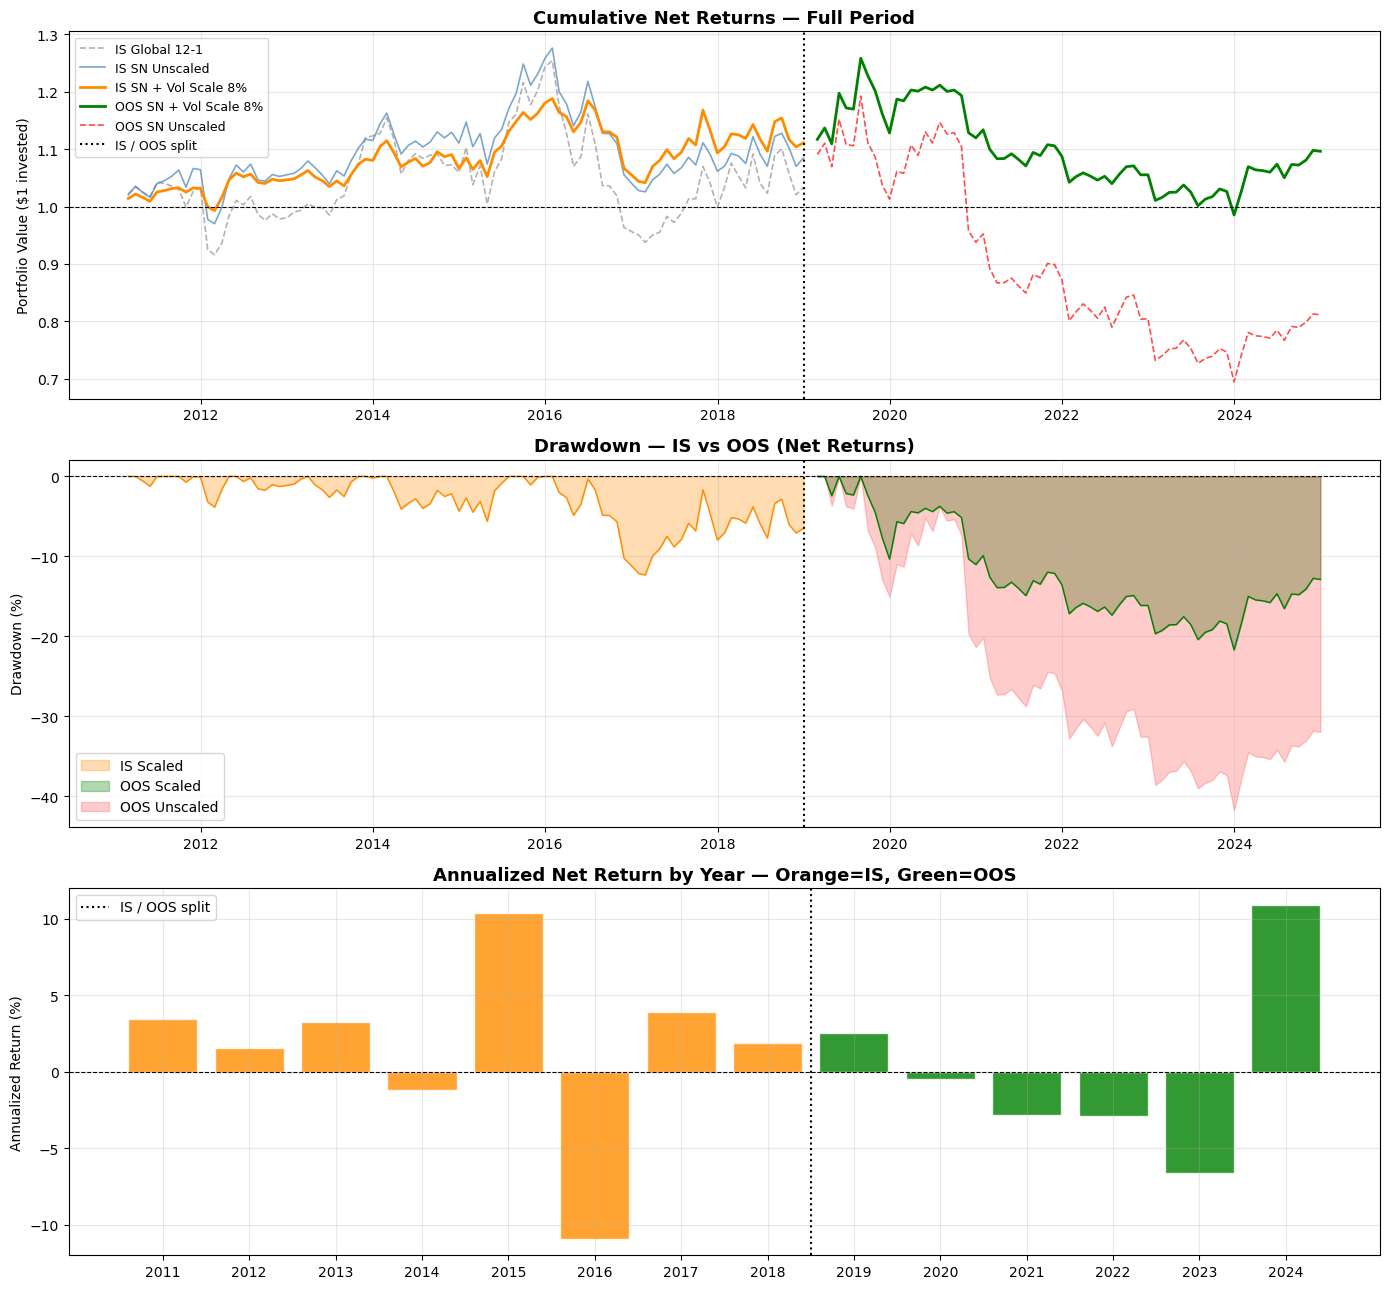

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13))

# Scaled IS and OOS cumulative returns
cum_scaled_is  = (1 + net_scaled_is.dropna()).cumprod()
cum_scaled_oos = (1 + port_net_oos_scaled.dropna()).cumprod()
cum_sn_is      = (1 + net_sn_is.dropna()).cumprod()
cum_global_is  = (1 + net_global_is.dropna()).cumprod()

# OOS continues from IS endpoint
oos_start_val  = cum_scaled_is.iloc[-1]
cum_scaled_oos_cont = cum_scaled_oos * oos_start_val

# Unscaled OOS
cum_oos_unscaled = (
    1 + port_net_oos_unscaled.dropna()
).cumprod() * cum_sn_is.iloc[-1]

# Plot 1: Cumulative returns full period
axes[0].plot(cum_global_is.index, cum_global_is.values,
             color='gray', linewidth=1.2,
             linestyle='--', alpha=0.6, label='IS Global 12-1')
axes[0].plot(cum_sn_is.index, cum_sn_is.values,
             color='steelblue', linewidth=1.2,
             alpha=0.7, label='IS SN Unscaled')
axes[0].plot(cum_scaled_is.index, cum_scaled_is.values,
             color='darkorange', linewidth=2.0,
             label='IS SN + Vol Scale 8%')
axes[0].plot(cum_scaled_oos_cont.index, cum_scaled_oos_cont.values,
             color='green', linewidth=2.0,
             label='OOS SN + Vol Scale 8%')
axes[0].plot(cum_oos_unscaled.index, cum_oos_unscaled.values,
             color='red', linewidth=1.2,
             linestyle='--', alpha=0.7,
             label='OOS SN Unscaled')
axes[0].axvline(pd.Timestamp(OOS_START),
                color='black', linewidth=1.5,
                linestyle=':', label='IS / OOS split')
axes[0].axhline(1.0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title(
    'Cumulative Net Returns — Full Period',
    fontsize=13, fontweight='bold'
)
axes[0].set_ylabel('Portfolio Value ($1 invested)')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(alpha=0.3)

# Plot 2: Drawdown
def compute_drawdown(returns):
    cum = (1 + returns.dropna()).cumprod()
    return (cum - cum.cummax()) / cum.cummax() * 100

dd_scaled_is  = compute_drawdown(net_scaled_is)
dd_scaled_oos = compute_drawdown(port_net_oos_scaled)
dd_sn_oos     = compute_drawdown(port_net_oos_unscaled)

axes[1].fill_between(dd_scaled_is.index, dd_scaled_is.values, 0,
                     alpha=0.3, color='darkorange', label='IS Scaled')
axes[1].fill_between(dd_scaled_oos.index, dd_scaled_oos.values, 0,
                     alpha=0.3, color='green', label='OOS Scaled')
axes[1].fill_between(dd_sn_oos.index, dd_sn_oos.values, 0,
                     alpha=0.2, color='red', label='OOS Unscaled')
axes[1].plot(dd_scaled_is.index, dd_scaled_is.values,
             color='darkorange', linewidth=1.0)
axes[1].plot(dd_scaled_oos.index, dd_scaled_oos.values,
             color='green', linewidth=1.0)
axes[1].axvline(pd.Timestamp(OOS_START),
                color='black', linewidth=1.5, linestyle=':')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Drawdown — IS vs OOS (Net Returns)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot 3: Annual net returns
all_net = pd.concat([net_scaled_is, port_net_oos_scaled])
ann_ret = all_net.groupby(all_net.index.year).mean() * 12
colors_yr = [
    'darkorange' if y <= 2018 else 'green'
    for y in ann_ret.index
]
axes[2].bar(ann_ret.index, ann_ret.values * 100,
            color=colors_yr, alpha=0.8, edgecolor='white')
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].axvline(2018.5, color='black', linewidth=1.5,
                linestyle=':', label='IS / OOS split')
axes[2].set_title(
    'Annualized Net Return by Year — Orange=IS, Green=OOS',
    fontsize=13, fontweight='bold'
)
axes[2].set_ylabel('Annualized Return (%)')
axes[2].set_xticks(ann_ret.index)
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/oos_full_period.png', dpi=150, bbox_inches='tight')
plt.show()